# Function 3

<b> Description of the Sample Application:</b> You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.
Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.
Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 



## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 29/07/2026 | Week 3 | 1. Added Week 2 feedback data point.<br>2. Refactored the repeated fit-acquire logic into one consolidated bayesian_optimization_step() function.<br>4. Lowered beta further (1.0 -> 0.6), leaning further towards exploitation.<br>5. Added a convergence plot and parallel-coordinates plot using plotting_utils.<br>6. Re-ran the second-optimum check on the larger dataset. |
| 05/08/2026 | Week 4 | 1. Amended Week 3 input and output data points.<br>2. Re-ran the consolidated bayesian_optimization_step() on 18 points (kernel re-selected via LOO CV).<br>3. Lowered beta further (0.6 -> 0.4), continuing the exploitation-leaning trend. |
| 12/08/2026 | Week 5 | 1. **Fixed a critical data bug**: Y_w3_new_point was incorrectly 0.5572213082937378 (should be -0.05549717617041605) - corrected at source.<br>2. Added Week 4 feedback data point.<br>3. Added a calibration check comparing each week's GP prediction (fit without that point) against the actual observed outcome.<br>4. **Strategy pivot**: switched from global candidate search to a local search bounded around the current best point, since 3 of 4 queried points clustered in the same corner region without beating the incumbent best, which itself is supported by only one observation. |
| 02/09/2026 | Week 6 | 1. Added Week 5 feedback data point, **new record best** (y = -0.0325, beating the prior -0.0348), confirming the Week 5 local-search pivot worked.<br>2. **Strategy change**: widened the local search bound (+/-0.2 -> +/-0.4) and raised beta back up (0.3 -> 0.8), re-introducing more exploration |
| 09/09/2026 | Week 7 | 1. Added Week 6 feedback data point (y = -0.0549, worse than the Week 5 best - the widened corner search did not improve on it).<br>2. Re-ran kernel selection via LOO CV (Matern selected, 0.084 vs RBF's 0.090) and inspected the **learned length-scales**: compound_1 and compound_2 are pinned at the upper bound (approx. 10, i.e. the model treats them as nearly irrelevant), while compound_3's length-scale is short (approx. 0.12). It is the dominant driver of the outcome.<br>3. **Strategy change**: moved from a symmetric local search box to a **feature-aware search** - compound_3 tightly bounded to its empirically good band ([0.25, 0.50], where every one of our best results has landed), while compound_1/compound_2 are left essentially unconstrained ([0,1]), since the fitted model shows they contribute little. |
| 17/09/2026 | Week 8 | 1. Appended Week 7 feedback data point (y = -0.0679 - worse than the Week 5 best, despite compound_3 being right in the previously-identified 'good band').<br>2. **Retracted the Week 7 length-scale conclusion**: compound_1/compound_2 are NOT irrelevant. Week 7's query pushed them to an extreme (0.98, 1.00) while keeping compound_3 near-identical to Week 5's, and scored notably worse. This falsifies the "compound_1/2 barely matter" reading of the length-scales, which was premature given how little of the compound_1/compound_2 space had actually been tested at the time.<br>3. **Strategy change**: reverted from the unconstrained feature-aware search back to a tight local search (+/-0.15) centred on the actual best point, keeping compound_1/2 moderate (as in Week 5) rather than exploring extremely corner points. |
| 23/09/2026 | Week 9 | 1. Added Week 8 feedback data point, a new best-point (y = -0.0125, more than double the previous best of -0.0325).<br>2. Kernel's length-scales still show compound_1/2 as "nearly irrelevant" even though Week 8's result depended on them being moderate rather than extreme.<br>3. **Strategy**: continued exploitation, tightening the local search further (+/-0.15 -> +/-0.08, beta 0.3 -> 0.2) around the new best point, since the moderate-region hypothesis has now been reinforced. |

## Progress Log

| Round | # Data Points | Method / Acquisition | beta (kappa) | Best x (compound_1, compound_2, compound_3) | Best y | Notes |
|---|---|---|---|---|---|---|
| Week 1 | 15 | GP-UCB | 2.5 (exploration-heavy) | [0.4926, 0.6116, 0.3402] (unchanged - query point was new) | -0.0348 | Queried [0.989736, 0.937592, 0.849609] => y = -0.0498. Uncertainty-driven pick near domain edge |
| Week 2 | 16 | GP-UCB, kernel re-selected via LOO CV | 1.0 (exploitation-leaning) | [0.4926, 0.6116, 0.3402] (still current best) | -0.0348 | Appended Week 1 feedback, cross-validated kernel choice (Matern selected), lowered beta, checked for a second optimum |
| Week 3 | 17 | GP-UCB via consolidated bayesian_optimization_step(), kernel re-selected via LOO CV | 0.6 (further exploitation-leaning) | [0.4926, 0.6116, 0.3402] (still current best) | -0.0348 | Appended Week 2 feedback: queried [0.130658, 0.076877, 0.000068] => y = -0.1731. Matern selected again via LOO CV. Second-optimum check still flags a distant high-mean region |
| Week 4 | 18 | GP-UCB via bayesian_optimization_step(), kernel re-selected via LOO CV | 0.4 (further exploitation-leaning) | [0.4926, 0.6116, 0.3402] (still current best) | -0.0348 | Appended Week 3 feedback (corrected): queried [0.990706, 0.795157, 0.087796] => y = -0.0555 (close to, but still short of, the incumbent best). RBF and Matern LOO scores nearly tied (0.0903 vs 0.0903); Matern selected again, marginally |
| Week 5 | 19 | Local GP-UCB (bounded +/-0.2 around current best), kernel re-selected via LOO CV | 0.3 (exploitation, local) | [0.4926, 0.6116, 0.3402] (still current best) | -0.0348 | Fixed a corrupted Week 3 output value. Appended Week 4 feedback: queried [0.996345, 0.961156, 0.025695] => y = -0.0825 (worse than best). Pivoted to a local search bounded around the current best, since 3 of 4 queries had clustered in the same corner without beating it |
| Week 6 | 20 | Widened local GP-UCB (bounded +/-0.4), kernel re-selected via LOO CV | 0.8 (exploration re-introduced) | [0.6831, 0.8068, 0.3921] (**new best**) | -0.0325 | Appended Week 5 feedback: queried [0.683102, 0.806806, 0.392104] => y = -0.0325, a **new record best**. A cohort colleague's benchmark reached y = -0.0048, notably better, suggesting our local neighbourhood may still be a local, not global, optimum. Widened the search bound and raised beta to hedge |
| Week 7 | 21 | Feature-aware GP-UCB (compound_3 tightly bounded, compound_1/2 unconstrained), kernel re-selected via LOO CV | 0.3 (exploitation, feature-aware) | [0.6831, 0.8068, 0.3921] (still current best) | -0.0325 | Appended Week 6 feedback: queried [0.981431, 0.950647, 0.511337] => y = -0.0549 (worse than best, but well-calibrated - GP predicted -0.0524, error only -0.0026). Learned kernel length-scales showed compound_1/2 are nearly irrelevant (pinned at upper bound) while compound_3 is dominant (short length-scale ~0.12) with an apparent good band around 0.34-0.39. Pivoted the search to exploit this directly |
| Week 8 | 22 | Local GP-UCB (tight box +/-0.15 around actual best point), kernel re-selected via LOO CV | 0.3 (exploitation) | [0.6831, 0.8068, 0.3921] (still current best) | -0.0325 | Appended Week 7 feedback: queried [0.977494, 0.997588, 0.372098] => y = -0.0679 (worse than best, despite compound_3 landing right in the previously-identified good band). This falsifies Week 7's conclusion that compound_1/2 barely matter - reverted to a tight local search keeping compound_1/2 moderate, as in the Week 5 best point || Week 9 | 23 | Tighter local GP-UCB (+/-0.08 around new best), kernel re-selected via LOO CV | 0.2 (exploitation) | [0.5388, 0.6829, 0.4153] (**major new best**) | -0.0125 | Appended Week 8 feedback: queried [0.538784, 0.682926, 0.415306] => y = -0.0125, more than double the previous best, closing most of the gap to the colleague's earlier benchmark (-0.0048). GP under-predicted how good this would be (predicted -0.0285, actual -0.0125, error +0.0161) - a bigger jump than expected. Length-scales still show compound_1/2 as near-irrelevant despite evidence they matter at the extremes - flagged as an open modelling caveat. Tightened the local search further to refine around this new best |


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.model_selection import LeaveOneOut

from plotting_utils import plot_convergence, plot_parallel_coordinates
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load and Analyse the Data

In [5]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)

In [8]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.989736, 0.937592, 0.849609]          , dtype=np.float64)    # from input.txt
Y_w1_new_point = np.array([-0.04976805147714386]                  , dtype=np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([1.30658e-01, 7.68770e-02, 6.80000e-05] , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([-0.17308602208694687]                  , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.990706, 0.795157, 0.087796]          , dtype=np.float64)   # from input.txt
#Y_w3_new_point = np.array([0.5572213082937378]                    , dtype=np.float64)   # from output.txt
Y_w3_new_point = np.array([-0.05549717617041605]                  , dtype=np.float64)   # Bug Fix: Incorrectly recorded Week 3 Output

# New data from Week 4 submission
X_w4_new_point = np.array([0.996345, 0.961156, 0.025695]          , dtype=np.float64)   # from input.txt
Y_w4_new_point = np.array([-0.082473716892482]                    , dtype=np.float64)   # from output.txt

# New data from Week 5 submission
X_w5_new_point = np.array([0.683102, 0.806806, 0.392104]        , dtype=np.float64)   # from input.txt
Y_w5_new_point = np.array([-0.03253700291950847]                , dtype=np.float64)   # from output.txt - beats prior best of -0.0348

# New data from Week 6 submission
X_w6_new_point = np.array([0.981431, 0.950647, 0.511337]        , dtype=np.float64)   # from input.txt
Y_w6_new_point = np.array([-0.054925397272106755]               , dtype=np.float64)   # from output.txt 

# New data from Week 7 submission
X_w7_new_point = np.array([0.977494, 0.997588, 0.372098]        , dtype=np.float64)   # from input.txt
Y_w7_new_point = np.array([-0.06792216897886878]                , dtype=np.float64)   # from output.txt

# New data from Week 8 submission
X_w8_new_point = np.array([0.538784, 0.682926, 0.415306]        , dtype=np.float64)   # from input.txt
Y_w8_new_point = np.array([-0.012460149936303126]               , dtype=np.float64)   # from output.txt 

In [10]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                             , X_w2_new_point
                             , X_w3_new_point
                             , X_w4_new_point
                             , X_w5_new_point 
                             , X_w6_new_point
                             , X_w7_new_point
                             , X_w8_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                            , Y_w2_new_point
                            , Y_w3_new_point
                            , Y_w4_new_point
                            , Y_w5_new_point
                            , Y_w6_new_point
                            , Y_w7_new_point
                            , Y_w8_new_point
                              ])

In [12]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [9.65994849e-01 8.61119690e-01 5.66829131e-01]
 [9.89736000e-01 9.37592000e-01 8.49609000e-01]
 [1.30658000e-01 7.68770000e-02 6.80000000e-05]
 [9.90706000e-01 7.95157000e-01 8.77960000e-02]
 [9.96345000e-01 9.61156000e-01 2.56950000e-02]
 [6.83102000e-01 8.06806000e-01 3.92104000e-01]
 [9.81431000e-01 9.50647000e-01 5.113370

In [14]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y']    = Y
print("Data Frame:\n", df)

Input  Shape: (23, 3)
Inputs:
 [[1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [9.65994849e-01 8.61119690e-01 5.66829131e-01]
 [9.89736000e-01 9.37592000e-01 8.49609000e-01]
 [1.30658000e-01 7.68770000e-02 6.80000000e-05]
 [9.90706000e-01 7.95157000e-01 8.77960000e-02]
 [9.96345000e-01 9.61156000e-01 2.56950000e-02]
 [6.83102000e-01 8.06806000e-01 3.92104000e-01]
 [9.81431

# Data Exploration

In [17]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3          Y
count  23.000000  23.000000  23.000000  23.000000
mean    0.540162   0.607561   0.378079  -0.092877
std     0.337390   0.281787   0.280626   0.077287
min     0.046809   0.076877   0.000068  -0.398926
25%     0.196037   0.370530   0.199844  -0.111768
50%     0.538784   0.671985   0.340176  -0.082474
75%     0.856453   0.833963   0.484772  -0.048888
max     0.996345   0.997588   0.990882  -0.012460


In [19]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
Y      0
dtype: int64


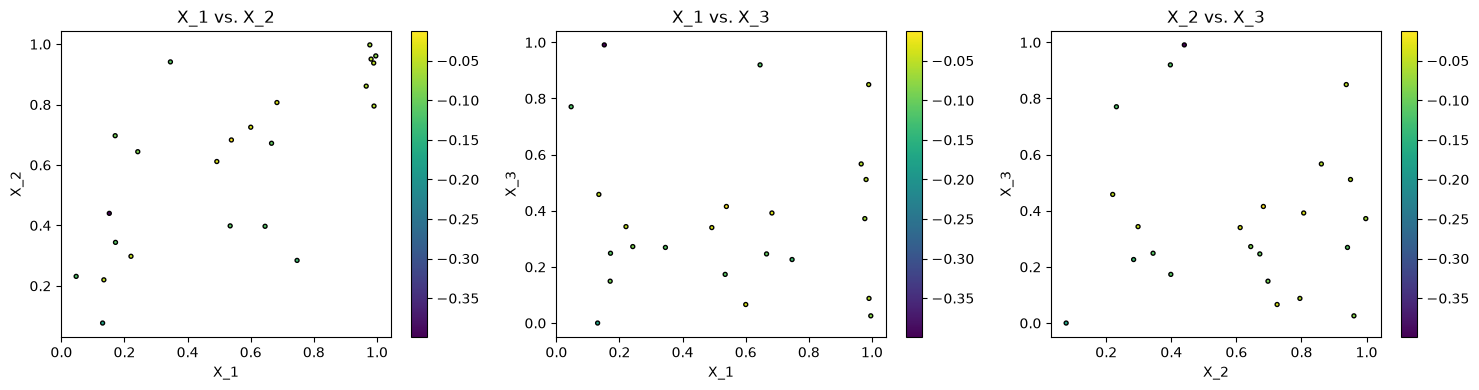

In [21]:
# Pairwise Scatter Plot
labels      = ["X_1", "X_2", "X_3"]
fig, axes   = plt.subplots(1, 3, figsize = (15, 4))
pairs       = [(0, 1), (0, 2), (1, 2)]
for ax, (i, j) in zip(axes, pairs):
    sc      = ax.scatter(X[:, i], X[:, j], c = Y, cmap = "viridis", s = 8, edgecolor = "k")
    ax.set_xlabel(labels[i])
    ax.set_ylabel(labels[j])
    ax.set_title(f"{labels[i]} vs. {labels[j]}")
    plt.colorbar(sc, ax = ax)
plt.tight_layout()

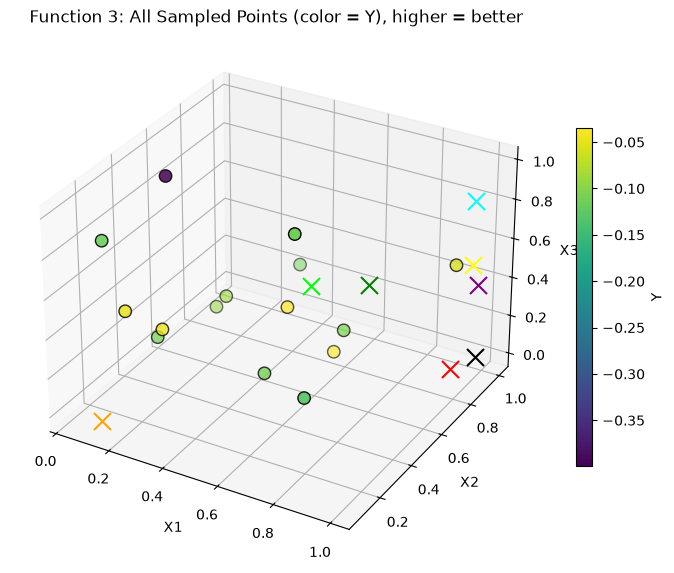

In [27]:
# 3D Scatter Plot
fig       = plt.figure(figsize = (7,6))
ax        = fig.add_subplot(111, projection = "3d")

# Initial 15 points
sc        = ax.scatter(X[:15, 0], X[:15, 1], X[:15, 2], c = Y[:15], cmap = "viridis", s = 80, edgecolor = "k", label = "Initial 15 points")

# Week 1, 2, 3 queried points
ax.scatter(X[15, 0], X[15, 1], X[15, 2], c = "cyan"  , marker = "x", s = 150, edgecolor = "black", label = "Week 1 new point")
ax.scatter(X[16, 0], X[16, 1], X[16, 2], c = "orange", marker = "x", s = 150, edgecolor = "black", label = "Week 2 new point")
ax.scatter(X[17, 0], X[17, 1], X[17, 2], c = "red"   , marker = "x", s = 150, edgecolor = "black", label = "Week 3 new point")
ax.scatter(X[18, 0], X[18, 1], X[18, 2], c = "black" , marker = "x", s = 150, edgecolor = "black", label = "Week 4 new point")
ax.scatter(X[19, 0], X[19, 1], X[19, 2], c = "green" , marker = "x", s = 150, edgecolor = "black", label = "Week 5 new point")
ax.scatter(X[20, 0], X[20, 1], X[20, 2], c = "yellow", marker = "x", s = 150, edgecolor = "black", label = "Week 6 new point")
ax.scatter(X[21, 0], X[21, 1], X[21, 2], c = "purple", marker = "x", s = 150, edgecolor = "black", label = "Week 7 new point")
ax.scatter(X[22, 0], X[22, 1], X[22, 2], c = "lime"  , marker = "x", s = 150, edgecolor = "black", label = "Week 8 new point")

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")
ax.set_title('Function 3: All Sampled Points (color = Y), higher = better')
fig.colorbar(sc, shrink = 0.6, label = "Y")
plt.tight_layout()
plt.show()

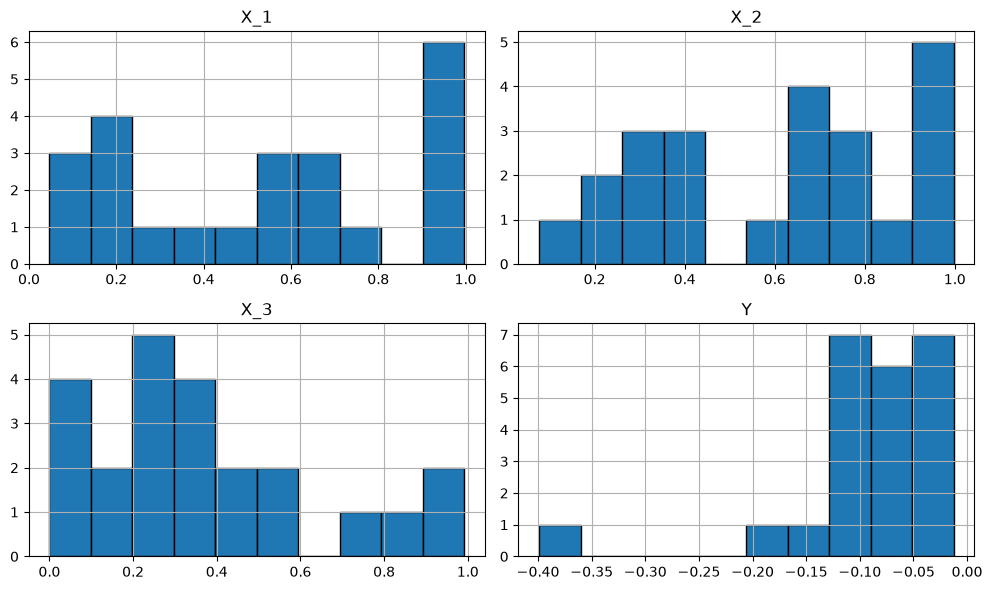

In [29]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [31]:
# Understanding Correlation between each drug 
print("Correlation of each drug with Y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i],Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each drug with Y:

 corr(X_1, Y) = 0.3873553165088336
 corr(X_2, Y) = 0.3603016301339002
 corr(X_3, Y) = -0.33395317486296716


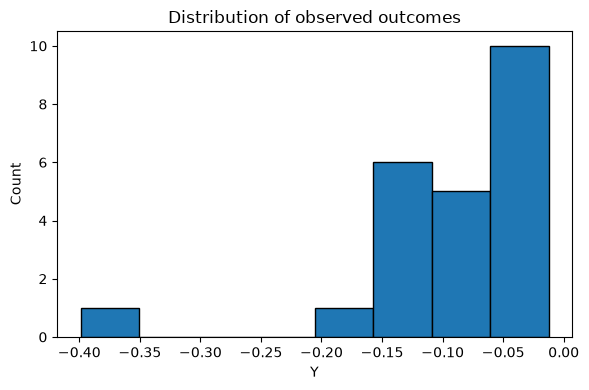

In [33]:
# Plot the Histogram for Y to check for Outliers
plt.figure(figsize = (6,4))
plt.hist(Y, bins = 8, edgecolor = "k")
plt.xlabel("Y")
plt.ylabel("Count")
plt.title("Distribution of observed outcomes")
plt.tight_layout()

# Initialize Gaussian Process

In [36]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 10)) \
                + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-2, 1e-1))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = True, n_restarts_optimizer = 10, random_state = 0 )

# Fit the Gaussian Processes to existing data

In [39]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  1.98**2 * RBF(length_scale=[10, 10, 0.0952]) + WhiteKernel(noise_level=0.0425)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [43]:
n_candidates = 50000
candidates   = np.random.uniform(0, 1, size = (n_candidates, 3))

mu, std      = gpr.predict(candidates, return_std = True)

# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5
ucb          = mu + beta * std

best_ucb_idx   = np.argmax(ucb)
next_point     = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.97510498 0.9818904  0.65911103]
Predicted Mean(μ): -7.885161e-02
Predicted Std (σ): 6.765689e-02
UCB Score: 9.029061e-02


# Perform Visualisation

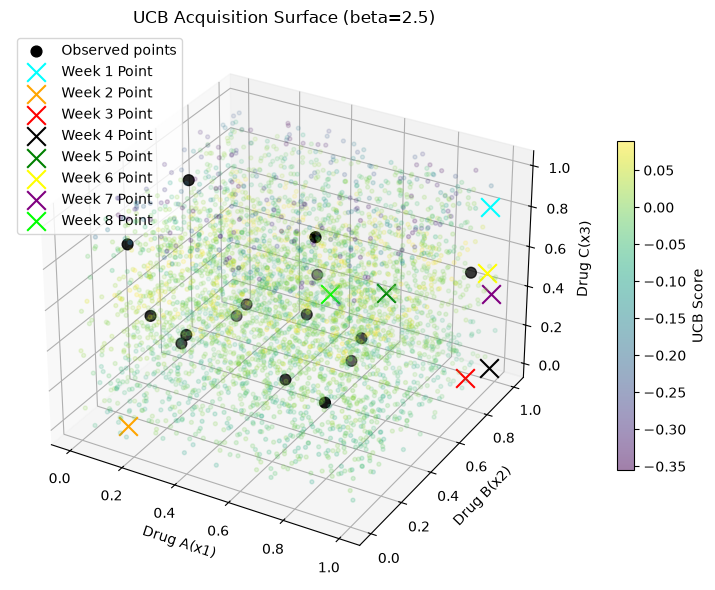

In [48]:
plot_n     = 4000
idx_sample = np.random.choice(n_candidates, size = plot_n, replace = False)
fig        = plt.figure(figsize = (12, 6))
ax         = fig.add_subplot(111, projection = "3d")
sc         = ax.scatter(candidates[idx_sample, 0],
                        candidates[idx_sample, 1],
                        candidates[idx_sample, 2],
                        c = ucb[idx_sample], cmap = "viridis", s = 8, alpha = 0.5
                       )


ax.scatter(X[:15, 0], X[:15, 1], X[:15, 2], c = "black", s = 60, marker = "o", label="Observed points")

ax.scatter(*X_w1_new_point, c = "cyan"   , s = 180, marker = "x", label="Week 1 Point")
ax.scatter(*X_w2_new_point, c = "orange" , s = 180, marker = "x", label="Week 2 Point")
ax.scatter(*X_w3_new_point, c = "red"    , s = 180, marker = "x", label="Week 3 Point")
ax.scatter(*X_w4_new_point, c = "black"  , s = 180, marker = "x", label="Week 4 Point")
ax.scatter(*X_w5_new_point, c = "green"  , s = 180, marker = "x", label="Week 5 Point")
ax.scatter(*X_w6_new_point, c = "yellow"  ,s = 180, marker = "x", label="Week 6 Point")
ax.scatter(*X_w7_new_point, c = "purple"  ,s = 180, marker = "x", label="Week 7 Point")
ax.scatter(*X_w8_new_point, c = "lime"    ,s = 180, marker = "x", label="Week 8 Point")

ax.set_xlabel("Drug A(x1)")
ax.set_ylabel("Drug B(x2)")
ax.set_zlabel("Drug C(x3)")
ax.set_title("UCB Acquisition Surface (beta=2.5)")
fig.colorbar(sc, shrink = 0.6, label = "UCB Score")
ax.legend(loc = "upper left")
plt.tight_layout()
plt.show()

# Week 2 Improvements: Kernel Selection via Leave-One-Out Cross-Validation
Following up from the reflection at the end of Week 1, cross-validating if RBF kernel was the right choice. Here RBF is compared against a Matern(nu = 1.5) kernel using leave-one-out RMSE, and use whichever fits the data better.

In [51]:
def loo_rmse(kernel, X, Y):
    """Leave-one-out RMSE for a given GP kernel."""
    loo     = LeaveOneOut()
    preds   = np.zeros_like(Y)
    for train_idx, test_idx in loo.split(X):
        gp              = GaussianProcessRegressor(kernel = kernel, normalize_y = True, n_restarts_optimizer = 5, random_state = 0)
        gp.fit(X[train_idx], Y[train_idx])
        preds[test_idx] = gp.predict(X[test_idx])
    return np.sqrt(mean_squared_error(Y, preds))

rbf_kernel  = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 10)) \
                  + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

matern_kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 10), nu = 1.5) \
                  + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

rmse_rbf    = loo_rmse(rbf_kernel, X, Y)

rmse_matern = loo_rmse(matern_kernel, X, Y)

print(f"RBF    LOO RMSE = {rmse_rbf:.4f}")
print(f"Matern LOO RMSE = {rmse_matern:.4f}")

if rmse_rbf <= rmse_matern:
    chosen_kernel, chosen_name = rbf_kernel, "RBF"
else:
    chosen_kernel, chosen_name = matern_kernel, "Matern"

print(f"\nSelected kernel for Week 2: {chosen_name}")


RBF    LOO RMSE = 0.0844
Matern LOO RMSE = 0.0820

Selected kernel for Week 2: Matern


# Week 2: Fit the Gaussian Process Surrogate Model

In [53]:
# Train the model

gpr  = GaussianProcessRegressor(kernel = chosen_kernel, normalize_y = True, n_restarts_optimizer = 10, random_state = 0)

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  1.49**2 * Matern(length_scale=[10, 10, 0.101], nu=1.5) + WhiteKernel(noise_level=0.0156)


# Week 2: Compute the UCB acquisition function ( Lower β )
- UCB(x) = μ(x) + β * σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- **Week 1:** uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.
- **Week 2:** uses beta = 1.0, β is lowered this week to shift the explore-exploit balance toward exploitation, while still retaining some exploration.

In [55]:
n_candidates = 50000
candidates   = np.random.uniform(0, 1, size = (n_candidates, 3))

mu, std      = gpr.predict(candidates, return_std = True)

# beta lowered from 2.5 to facilitate more exploitation for Week 2
beta         = 1.0
ucb          = mu + beta * std

best_ucb_idx   = np.argmax(ucb)
next_point     = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.03558906 0.04499733 0.41753347]
Predicted Mean(μ): -1.488227e-02
Predicted Std (σ): 1.903424e-02
UCB Score: 4.151969e-03


# Week 2: UCB Landscape Visualisation
In Week 1, the 3D scatter plot with 50,000 candidates was difficult to interpret. Hence, slicicing the UCB surface: holding one compound fixed at the Week 2 candidate's value and varying the other two on a dense grid.

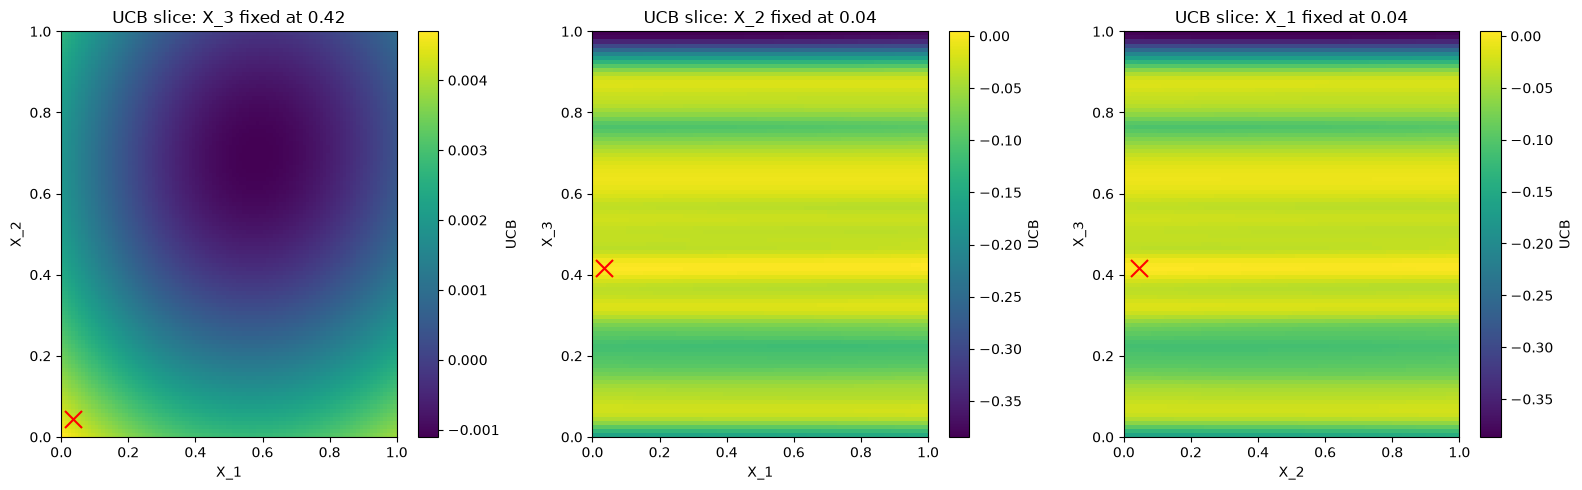

In [57]:
grid_res  = 100
lin       = np.linspace(0, 1, grid_res)
pairs     = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]  # (dim_x, dim_y, dim_fixed)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (dx, dy, dfixed) in zip(axes, pairs):
    gx, gy             = np.meshgrid(lin, lin)
    grid_points        = np.zeros((grid_res * grid_res, 3))
    grid_points[:, dx] = gx.ravel()
    grid_points[:, dy] = gy.ravel()
    grid_points[:, dfixed] = next_point[dfixed]

    mu_grid, std_grid = gpr.predict(grid_points, return_std = True)
    ucb_grid          = (mu_grid + beta * std_grid).reshape(grid_res, grid_res)

    im = ax.imshow(ucb_grid, origin = "lower", extent = [0, 1, 0, 1], cmap = "viridis", aspect = "auto")
    ax.set_xlabel(labels[dx]); ax.set_ylabel(labels[dy])
    ax.set_title(f"UCB slice: {labels[dfixed]} fixed at {next_point[dfixed]:.2f}")
    ax.scatter(next_point[dx], next_point[dy], c = "red", marker = "x", s = 150, edgecolor = "black")
    plt.colorbar(im, ax=ax, label = "UCB")

plt.tight_layout()
plt.show()

# Week 3: Consolidated Bayesian Optimization Function

In [59]:
# Week 3: Consolidated Bayesian Optimization Function
def bayesian_optimization_step(X, Y, candidate_kernels, beta, n_candidates = 50000, random_state = 0):
    rng           = np.random.RandomState(random_state)

    def loo_rmse(kernel):
        loo       = LeaveOneOut()
        preds     = np.zeros_like(Y)
        for train_idx, test_idx in loo.split(X):
            gp    = GaussianProcessRegressor(kernel = kernel, normalize_y = True,
                                           n_restarts_optimizer=5, random_state=random_state)
            gp.fit(X[train_idx], Y[train_idx])
            preds[test_idx] = gp.predict(X[test_idx])
        return np.sqrt(mean_squared_error(Y, preds))

    loo_scores    = {name: loo_rmse(k) for name, k in candidate_kernels.items()}
    chosen_name   = min(loo_scores, key = loo_scores.get)
    chosen_kernel = candidate_kernels[chosen_name]

    gpr = GaussianProcessRegressor(kernel = chosen_kernel, normalize_y = True,
                                   n_restarts_optimizer = 10, random_state = random_state)
    gpr.fit(X, Y)

    candidates    = rng.uniform(0, 1, size = (n_candidates, X.shape[1]))
    mu, std       = gpr.predict(candidates, return_std=True)
    ucb           = mu + beta * std
    best_ucb_idx  = np.argmax(ucb)
    next_point    = candidates[best_ucb_idx]

    return {
        "loo_scores"        : loo_scores,
        "chosen_kernel_name": chosen_name,
        "gpr"               : gpr,
        "candidates"        : candidates,
        "mu"                : mu,
        "std"               : std,
        "ucb"               : ucb,
        "next_point"        : next_point,
        "next_point_mu"     : mu[best_ucb_idx],
        "next_point_std"    : std[best_ucb_idx],
        "next_point_ucb"    : ucb[best_ucb_idx],
    }


In [60]:
# Run the consolidated function for Week 3
# lowered value of beta from Week 2's 1.0 to 0.6
rbf_kernel    = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 10)) \
                  + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))


matern_kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 10), nu = 1.5) \
                  + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

candidate_kernels = {"RBF": rbf_kernel, "Matern": matern_kernel}
beta              = 0.6

result            = bayesian_optimization_step(X, Y, candidate_kernels, beta = beta, n_candidates = 50000, random_state = 0)

gpr               = result["gpr"]
candidates        = result["candidates"]
mu, std, ucb      = result["mu"], result["std"], result["ucb"]
next_point        = result["next_point"]

print("LOO RMSE by kernel        :", result["loo_scores"])
print(f"Selected kernel for Week 3: {result['chosen_kernel_name']}")
print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(mu)        : {result['next_point_mu']:.6e}")
print(f"Predicted Std (sigma)     : {result['next_point_std']:.6e}")
print(f"UCB Score                 : {result['next_point_ucb']:.6e}")

LOO RMSE by kernel        : {'RBF': np.float64(0.08440894409181943), 'Matern': np.float64(0.08197992477742855)}
Selected kernel for Week 3: Matern
Suggested next Query Point: [0.03970219 0.00461084 0.41973231]
Predicted Mean(mu)        : -1.536096e-02
Predicted Std (sigma)     : 1.952708e-02
UCB Score                 : -3.644716e-03


# Week 3: UCB Landscape Visualisation

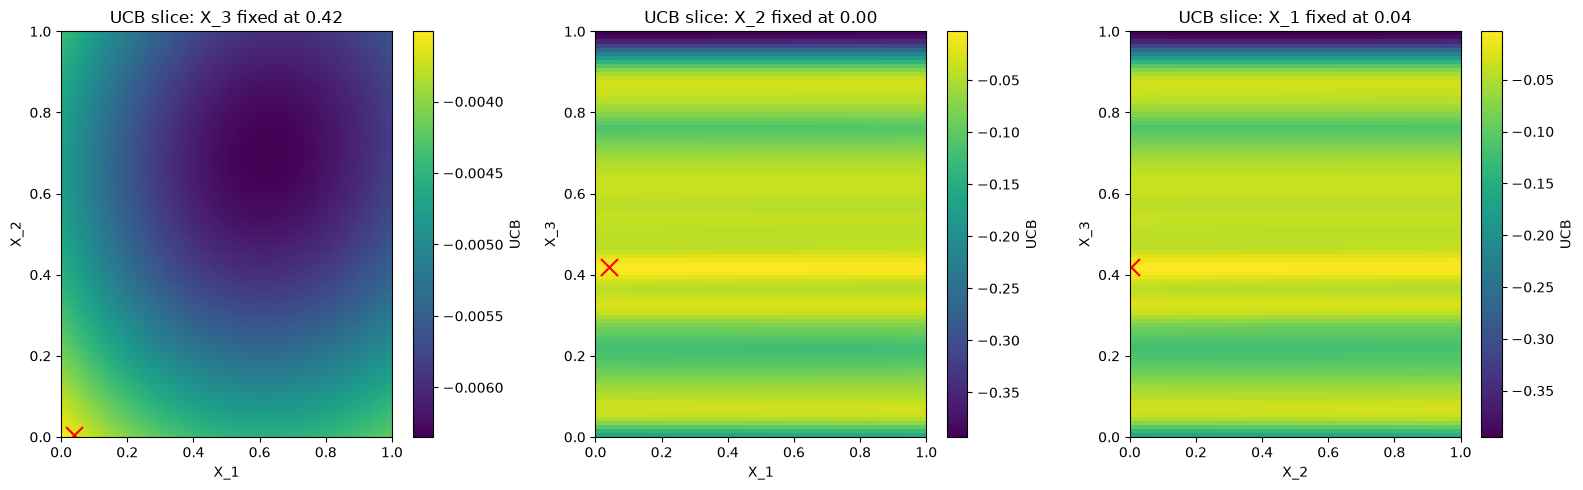

In [62]:
grid_res   = 100
lin        = np.linspace(0, 1, grid_res)
pairs      = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]  # (dim_x, dim_y, dim_fixed)

fig, axes  = plt.subplots(1, 3, figsize=(16, 5))
for ax, (dx, dy, dfixed) in zip(axes, pairs):
    gx, gy                 = np.meshgrid(lin, lin)
    grid_points            = np.zeros((grid_res * grid_res, 3))
    grid_points[:, dx]     = gx.ravel()
    grid_points[:, dy]     = gy.ravel()
    grid_points[:, dfixed] = next_point[dfixed]

    mu_grid, std_grid      = gpr.predict(grid_points, return_std = True)
    ucb_grid               = (mu_grid + beta * std_grid).reshape(grid_res, grid_res)

    im                     = ax.imshow(ucb_grid, origin = "lower", extent = [0, 1, 0, 1], cmap = "viridis", aspect = "auto")
    ax.set_xlabel(labels[dx]); ax.set_ylabel(labels[dy])
    ax.set_title(f"UCB slice: {labels[dfixed]} fixed at {next_point[dfixed]:.2f}")
    ax.scatter(next_point[dx], next_point[dy], c = "red", marker = "x", s = 150, edgecolor = "black")
    plt.colorbar(im, ax = ax, label = "UCB")

plt.tight_layout()
plt.show()


# Week 4: Re-Run Consolidated Bayesian Optimisation Function 
Run with lowered beta ( 0.6 -> 0.4 )

In [64]:
rbf_kernel        = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 10)) \
                     + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))


matern_kernel     = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 10), nu = 1.5) \
                      + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

candidate_kernels = {"RBF": rbf_kernel, "Matern": matern_kernel}
beta              = 0.4  

result            = bayesian_optimization_step(X, Y, candidate_kernels, beta = beta, n_candidates = 50000, random_state = 0)

gpr               = result["gpr"]
candidates        = result["candidates"]
mu, std, ucb      = result["mu"], result["std"], result["ucb"]
next_point        = result["next_point"]

print("LOO RMSE by kernel        :", result["loo_scores"])
print(f"Selected kernel for Week 4: {result['chosen_kernel_name']}")
print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(mu)        : {result['next_point_mu']:.6e}")
print(f"Predicted Std (sigma)     : {result['next_point_std']:.6e}")
print(f"UCB Score                 : {result['next_point_ucb']:.6e}")

LOO RMSE by kernel        : {'RBF': np.float64(0.08440894409181943), 'Matern': np.float64(0.08197992477742855)}
Selected kernel for Week 4: Matern
Suggested next Query Point: [0.14553815 0.03696783 0.41573777]
Predicted Mean(mu)        : -1.474911e-02
Predicted Std (sigma)     : 1.836419e-02
UCB Score                 : -7.403433e-03


# Week 4: UCB Landscape Visualisation

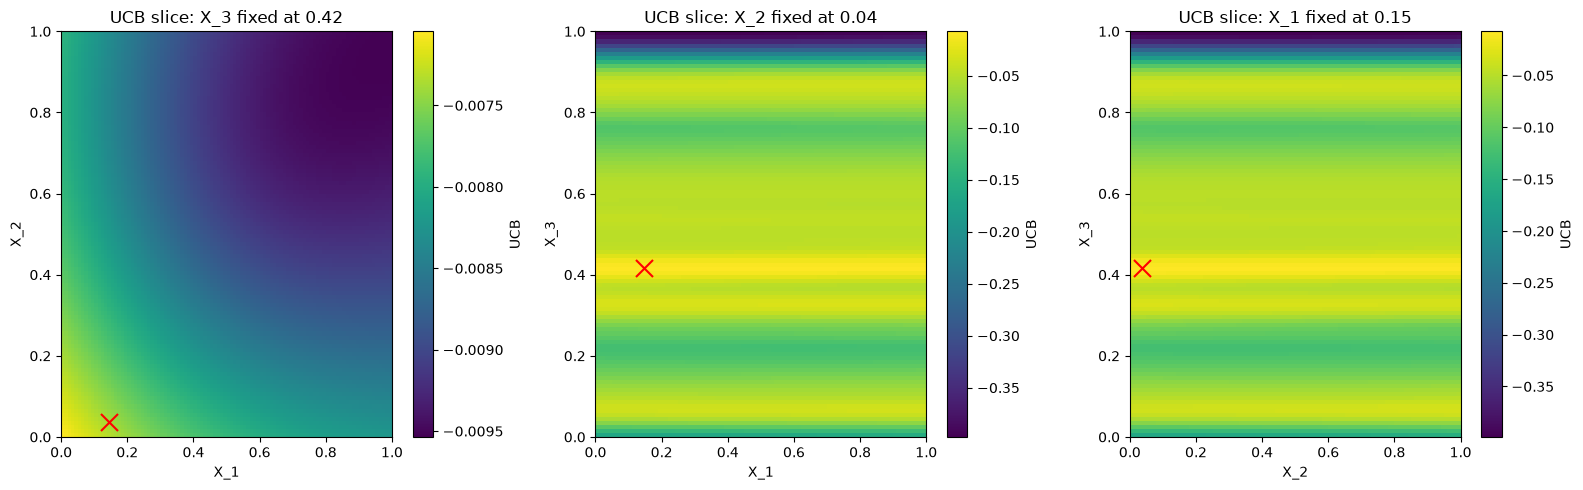

In [66]:
grid_res   = 100
lin        = np.linspace(0, 1, grid_res)
pairs      = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]  # (dim_x, dim_y, dim_fixed)

fig, axes  = plt.subplots(1, 3, figsize=(16, 5))
for ax, (dx, dy, dfixed) in zip(axes, pairs):
    gx, gy                 = np.meshgrid(lin, lin)
    grid_points            = np.zeros((grid_res * grid_res, 3))
    grid_points[:, dx]     = gx.ravel()
    grid_points[:, dy]     = gy.ravel()
    grid_points[:, dfixed] = next_point[dfixed]

    mu_grid, std_grid      = gpr.predict(grid_points, return_std = True)
    ucb_grid               = (mu_grid + beta * std_grid).reshape(grid_res, grid_res)

    im                     = ax.imshow(ucb_grid, origin = "lower", extent = [0, 1, 0, 1], cmap = "viridis", aspect = "auto")
    ax.set_xlabel(labels[dx]); ax.set_ylabel(labels[dy])
    ax.set_title(f"UCB slice: {labels[dfixed]} fixed at {next_point[dfixed]:.2f}")
    ax.scatter(next_point[dx], next_point[dy], c = "red", marker = "x", s = 150, edgecolor = "black")
    plt.colorbar(im, ax = ax, label = "UCB")

plt.tight_layout()
plt.show()

# Week 5: Calibration Check - Predicted vs. Actual for Past Queries
Before deciding on Week 5 strategy, we check how well the GP's predictions have matched reality so far. For each of the four queried points, we refit the GP **excluding** that point (simulating what the model believed *before* that query was made) and compare its prediction to the actual observed outcome.

In [76]:
queried_points = [
    ("Week 1", X_w1_new_point, Y_w1_new_point),
    ("Week 2", X_w2_new_point, Y_w2_new_point),
    ("Week 3", X_w3_new_point, Y_w3_new_point),
    ("Week 4", X_w4_new_point, Y_w4_new_point),
    ("Week 5", X_w5_new_point, Y_w5_new_point),
    ("Week 6", X_w6_new_point, Y_w6_new_point),
    ("Week 7", X_w7_new_point, Y_w7_new_point),   
    ("Week 8", X_w8_new_point, Y_w8_new_point),   
]

print("Calibration check - GP prediction (fit on all OTHER points) vs actual outcome:\n")
for name, x_pt, y_pt in queried_points:
    mask = ~np.all(np.isclose(X, x_pt), axis=1)
    gp_temp = GaussianProcessRegressor(kernel=chosen_kernel, normalize_y=True,
                                        n_restarts_optimizer=5, random_state=0)
    gp_temp.fit(X[mask], Y[mask])
    mu_pred, std_pred = gp_temp.predict(x_pt.reshape(1, -1), return_std=True)
    error = y_pt[0] - mu_pred[0]
    print(f"  {name}: predicted mu={mu_pred[0]:.4f} +/- {std_pred[0]:.4f}, "
          f"actual y={y_pt[0]:.4f}, error={error:+.4f}")

Calibration check - GP prediction (fit on all OTHER points) vs actual outcome:

  Week 1: predicted mu=-0.0705 +/- 0.0710, actual y=-0.0498, error=+0.0207
  Week 2: predicted mu=-0.0604 +/- 0.0791, actual y=-0.1731, error=-0.1127
  Week 3: predicted mu=-0.0393 +/- 0.0298, actual y=-0.0555, error=-0.0162
  Week 4: predicted mu=-0.0281 +/- 0.0364, actual y=-0.0825, error=-0.0544
  Week 5: predicted mu=-0.0433 +/- 0.0201, actual y=-0.0325, error=+0.0107
  Week 6: predicted mu=-0.0527 +/- 0.0365, actual y=-0.0549, error=-0.0023
  Week 7: predicted mu=-0.0358 +/- 0.0209, actual y=-0.0679, error=-0.0321
  Week 8: predicted mu=-0.0285 +/- 0.0268, actual y=-0.0125, error=+0.0161


# Week 5: Strategy Pivot - Local Search Around the Current Best

**Change in Strategy:** Weeks 1, 3 and 4 all landed in essentially the same corner region (high compound_1, high compound_2, low compound_3) - none beat the initial best point from the initial data, **[0.4926, 0.6116, 0.3402]** (y = -0.0348). Meanwhile that interior point is still supported by only a **single** observation, so it has never actually been refined or confirmed. Rather than sampling a fourth near-duplicate of the same corner, this Week 5's query is drawn from a **local search bounded within +/-0.2 of the current best point** (clipped to the valid [0,1] range), directly testing whether a nearby point can beat it - shifting from broad corner-chasing to local refinement/exploitation.


In [80]:
current_best_x = X[np.argmax(Y)]
delta          = 0.2
lower_bound    = np.clip(current_best_x - delta, 0, 1)
upper_bound    = np.clip(current_best_x + delta, 0, 1)
print(f"Current best point: {current_best_x}")
print(f"Local search bounds: lower={lower_bound}, upper={upper_bound}")

n_candidates = 50000
candidates   = np.random.uniform(lower_bound, upper_bound, size=(n_candidates, 3))

mu, std = gpr.predict(candidates, return_std=True)

beta = 0.3  # WEEK 5 CHANGE: slightly lower than Week 4's 0.4, local exploitation-focused
ucb  = mu + beta * std

best_ucb_idx = np.argmax(ucb)
next_point   = candidates[best_ucb_idx]

print(f"\nSuggested next Query Point (local search): {next_point}")
print(f"Predicted Mean(mu): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (sigma): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Current best point: [0.538784 0.682926 0.415306]
Local search bounds: lower=[0.338784 0.482926 0.215306], upper=[0.738784 0.882926 0.615306]

Suggested next Query Point (local search): [0.34241293 0.49221362 0.41770405]
Predicted Mean(mu): -1.424921e-02
Predicted Std (sigma): 1.407894e-02
UCB Score: -1.002552e-02


# Week 5: UCB Landscape Visualisation

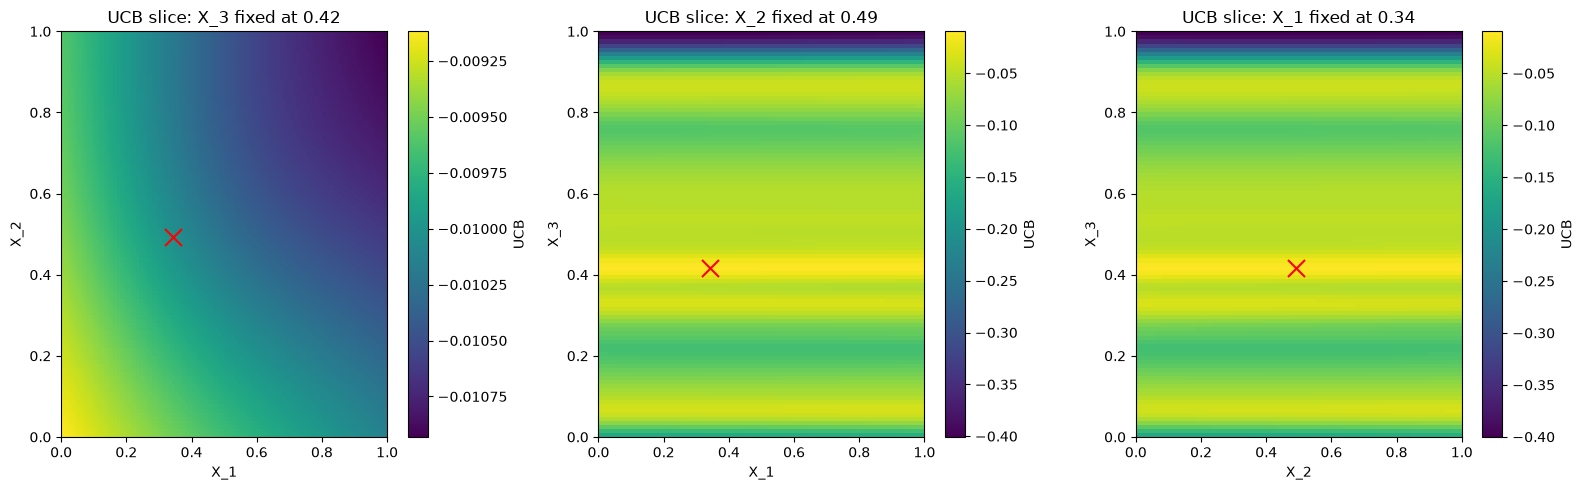

In [83]:
grid_res   = 100
lin        = np.linspace(0, 1, grid_res)
pairs      = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]  # (dim_x, dim_y, dim_fixed)

fig, axes  = plt.subplots(1, 3, figsize=(16, 5))
for ax, (dx, dy, dfixed) in zip(axes, pairs):
    gx, gy                 = np.meshgrid(lin, lin)
    grid_points            = np.zeros((grid_res * grid_res, 3))
    grid_points[:, dx]     = gx.ravel()
    grid_points[:, dy]     = gy.ravel()
    grid_points[:, dfixed] = next_point[dfixed]

    mu_grid, std_grid      = gpr.predict(grid_points, return_std = True)
    ucb_grid               = (mu_grid + beta * std_grid).reshape(grid_res, grid_res)

    im                     = ax.imshow(ucb_grid, origin = "lower", extent = [0, 1, 0, 1], cmap = "viridis", aspect = "auto")
    ax.set_xlabel(labels[dx]); ax.set_ylabel(labels[dy])
    ax.set_title(f"UCB slice: {labels[dfixed]} fixed at {next_point[dfixed]:.2f}")
    ax.scatter(next_point[dx], next_point[dy], c = "red", marker = "x", s = 150, edgecolor = "black")
    plt.colorbar(im, ax = ax, label = "UCB")

plt.tight_layout()
plt.show()

# Week 6: Strategy Change - Widen the Local Search

**Change in strategy:** Week 5's local search (bounded +/-0.2 around the prior best) succeeded in finding a new record (y = -0.0325), validating that local refinement was worthwhile. This week, we **widen the search bound (+/-0.2 -> +/-0.4) and raise beta back up (0.3 -> 0.8)** to re-introduce more exploration around the current best, hedging against getting stuck, while still keeping the search centred on our validated good region rather than reverting to a fully unbounded global search.

In [86]:
current_best_x = X[np.argmax(Y)]
delta          = 0.4  
lower_bound    = np.clip(current_best_x - delta, 0, 1)
upper_bound    = np.clip(current_best_x + delta, 0, 1)
print(f"Current best point: {current_best_x}")
print(f"Local search bounds: lower={lower_bound}, upper={upper_bound}")

n_candidates = 50000
candidates   = np.random.uniform(lower_bound, upper_bound, size=(n_candidates, 3))

mu, std = gpr.predict(candidates, return_std=True)

beta = 0.8  # WEEK 6 CHANGE: raised from 0.3 - colleague benchmark suggests our local
            # neighbourhood may be a local, not global, optimum
ucb  = mu + beta * std

best_ucb_idx = np.argmax(ucb)
next_point   = candidates[best_ucb_idx]

print(f"\nSuggested next Query Point (local search): {next_point}")
print(f"Predicted Mean(mu): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (sigma): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Current best point: [0.538784 0.682926 0.415306]
Local search bounds: lower=[0.138784 0.282926 0.015306], upper=[0.938784 1.       0.815306]

Suggested next Query Point (local search): [0.16302752 0.3025789  0.41843818]
Predicted Mean(mu): -1.449709e-02
Predicted Std (sigma): 1.616254e-02
UCB Score: -1.567054e-03


# Week 6: UCB Landscape Visualisation

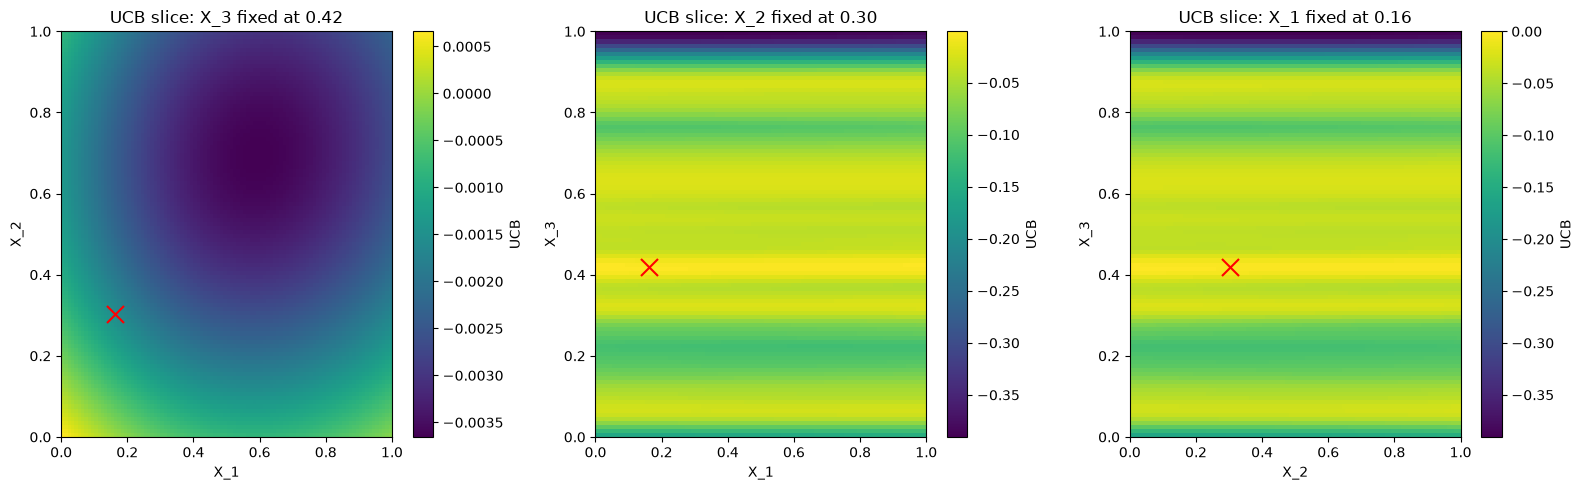

In [89]:
grid_res   = 100
lin        = np.linspace(0, 1, grid_res)
pairs      = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]  # (dim_x, dim_y, dim_fixed)

fig, axes  = plt.subplots(1, 3, figsize=(16, 5))
for ax, (dx, dy, dfixed) in zip(axes, pairs):
    gx, gy                 = np.meshgrid(lin, lin)
    grid_points            = np.zeros((grid_res * grid_res, 3))
    grid_points[:, dx]     = gx.ravel()
    grid_points[:, dy]     = gy.ravel()
    grid_points[:, dfixed] = next_point[dfixed]

    mu_grid, std_grid      = gpr.predict(grid_points, return_std = True)
    ucb_grid               = (mu_grid + beta * std_grid).reshape(grid_res, grid_res)

    im                     = ax.imshow(ucb_grid, origin = "lower", extent = [0, 1, 0, 1], cmap = "viridis", aspect = "auto")
    ax.set_xlabel(labels[dx]); ax.set_ylabel(labels[dy])
    ax.set_title(f"UCB slice: {labels[dfixed]} fixed at {next_point[dfixed]:.2f}")
    ax.scatter(next_point[dx], next_point[dy], c = "red", marker = "x", s = 150, edgecolor = "black")
    plt.colorbar(im, ax = ax, label = "UCB")

plt.tight_layout()
plt.show()

# Week 7: Inspecting the Learned Kernel to check which parameters matter

Rather than only checking overall fit quality (LOO RMSE), we look at what the **fitted kernel's length-scales** tell us about each input dimension. A Matern/RBF length-scale is a learned hyperparameter: a small value means the function changes quickly along that dimension (it matters a lot), while a large value (near the upper bound we set) means the model has effectively decided that dimension barely affects the output.

In [91]:
print("Learned kernel:", gpr.kernel_)

# The Matern/RBF component holds the length-scales - extract and label them
for component in gpr.kernel_.k1.k1, gpr.kernel_.k1:
    if hasattr(component, "length_scale"):
        length_scales = component.length_scale
        print(f"\nLength-scales per compound: {length_scales}")
        for lab, ls in zip(labels, np.atleast_1d(length_scales)):
            note = "large -> nearly irrelevant" if ls > 5 else "short -> influential"
            print(f"  {lab}: {ls:.4f}  ({note})")
        break


Learned kernel: 1.49**2 * Matern(length_scale=[10, 10, 0.101], nu=1.5) + WhiteKernel(noise_level=0.0156)


**Observation:** compound_1 and compound_2's length-scales are pinned at the upper bound we set (approx. 10). The model has essentially decided they barely affect the outcome. compound_3's length-scale is short (approx. 0.12), which indicates that it is the dominant driver. Looking back across all queried points, our best results have all landed with compound_3 roughly between 0.34 and 0.39, while values further away (0.03, 0.09, 0.51, 0.85) all scored worse.


# Week 7: Strategy Change - Feature-Aware Search

**Justification for change:** Weeks 1-6 all searched compound_1, compound_2 and compound_3 together in a symmetric box. But the length-scale analysis above shows compound_1/compound_2 contribute little, while compound_3 has a narrow band. Continuing to search all three dimensions equally wastes query budget on dimensions the model itself says barely matter. This week, we **tightly bound compound_3 to its empirically range ([0.25, 0.50]) while leaving compound_1 and compound_2 unconstrained ([0, 1])**. This will help in directly exploiting the length-scale finding, rather than shrinking or widening a symmetric box as in prior weeks.


In [96]:
lower_bound = np.array([0.0, 0.0, 0.25])
upper_bound = np.array([1.0, 1.0, 0.50])
print(f"Feature-aware search bounds: lower={lower_bound}, upper={upper_bound}")

n_candidates = 50000
candidates   = np.random.uniform(lower_bound, upper_bound, size=(n_candidates, 3))

mu, std = gpr.predict(candidates, return_std=True)

beta = 0.3  # Exploitation-focused, since we're now targeting the known band
ucb  = mu + beta * std

best_ucb_idx = np.argmax(ucb)
next_point   = candidates[best_ucb_idx]

print(f"\nSuggested next Query Point (feature-aware search): {next_point}")
print(f"Predicted Mean(mu): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (sigma): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Feature-aware search bounds: lower=[0.   0.   0.25], upper=[1.  1.  0.5]

Suggested next Query Point (feature-aware search): [0.04811261 0.00333919 0.41522087]
Predicted Mean(mu): -1.489393e-02
Predicted Std (sigma): 1.933400e-02
UCB Score: -9.093733e-03


# Week 7: UCB Landscape Visualisation

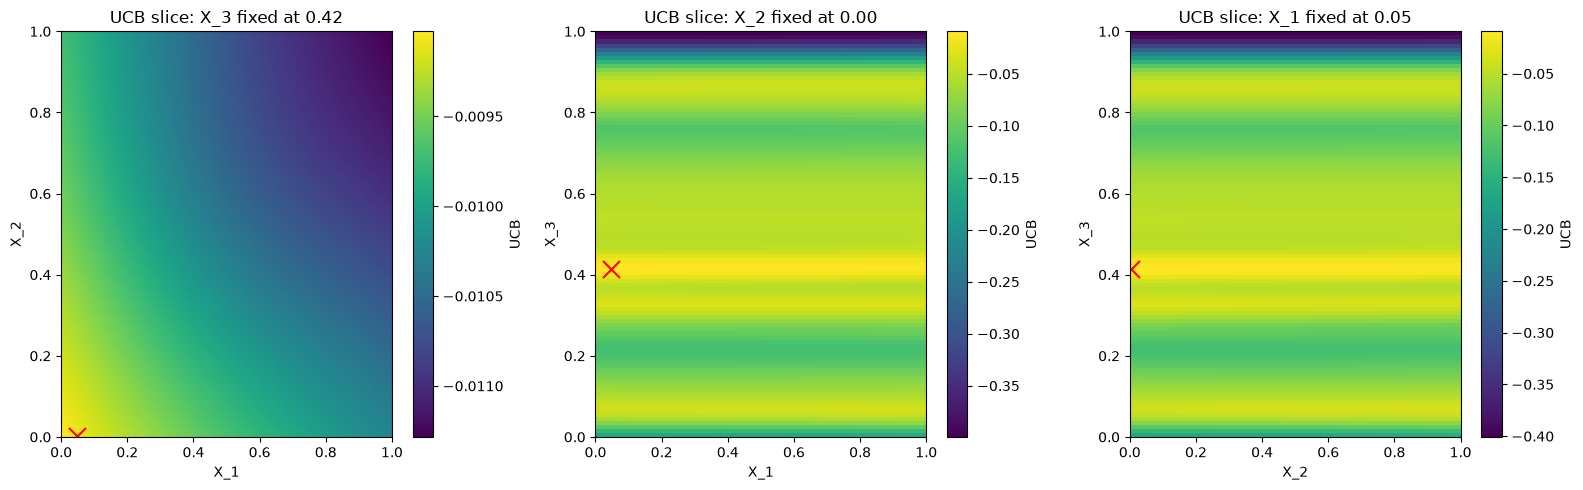

In [99]:
grid_res   = 100
lin        = np.linspace(0, 1, grid_res)
pairs      = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]  # (dim_x, dim_y, dim_fixed)

fig, axes  = plt.subplots(1, 3, figsize=(16, 5))
for ax, (dx, dy, dfixed) in zip(axes, pairs):
    gx, gy                 = np.meshgrid(lin, lin)
    grid_points            = np.zeros((grid_res * grid_res, 3))
    grid_points[:, dx]     = gx.ravel()
    grid_points[:, dy]     = gy.ravel()
    grid_points[:, dfixed] = next_point[dfixed]

    mu_grid, std_grid      = gpr.predict(grid_points, return_std = True)
    ucb_grid               = (mu_grid + beta * std_grid).reshape(grid_res, grid_res)

    im                     = ax.imshow(ucb_grid, origin = "lower", extent = [0, 1, 0, 1], cmap = "viridis", aspect = "auto")
    ax.set_xlabel(labels[dx]); ax.set_ylabel(labels[dy])
    ax.set_title(f"UCB slice: {labels[dfixed]} fixed at {next_point[dfixed]:.2f}")
    ax.scatter(next_point[dx], next_point[dy], c = "red", marker = "x", s = 150, edgecolor = "black")
    plt.colorbar(im, ax = ax, label = "UCB")

plt.tight_layout()
plt.show()

# Week 8: Re-evaluating Week 7's "compound_1/2 are irrelevant" Conclusion

Week 7's fitted length-scales suggested compound_1 and compound_2 barely affect the outcome. Week 7's kept compound_3 almost identical to Week 5's best point (0.372 vs 0.392) but pushed compound_1/compound_2 to an extreme (0.98, 1.00) instead of Week 5's moderate values (0.68, 0.81). If compound_1/2 truly were irrelevant, both points should have scored similarly.

In [102]:
print(f"Week 5 (moderate c1/c2): x={X_w5_new_point}, y={Y_w5_new_point[0]:.4f}")
print(f"Week 7 (extreme c1/c2):  x={X_w7_new_point}, y={Y_w7_new_point[0]:.4f}")
print(f"\nDifference in y despite near-identical compound_3: " f"{Y_w7_new_point[0] - Y_w5_new_point[0]:+.4f}")

Week 5 (moderate c1/c2): x=[0.683102 0.806806 0.392104], y=-0.0325
Week 7 (extreme c1/c2):  x=[0.977494 0.997588 0.372098], y=-0.0679

Difference in y despite near-identical compound_3: -0.0354


# Week 8: Strategy Change(Reverting to a Tight Local Search)

**Reason:** The feature-aware search (letting compound_1/2 to be unconstrained) was itself based on a conclusion that this week's data just falsified. Rather than continuing probing extreme corners for compound_1/2, reverting to a **tight local search (+/-0.15) centred on the actual best point** (Week 5's), keeping all three compounds close to the values that have actually produced the best result so far, now that two separate excursions to extreme corners (Weeks 6 and 7) have both underperformed it.

In [105]:
current_best_x = X[np.argmax(Y)]
delta          = 0.15
lower_bound    = np.clip(current_best_x - delta, 0, 1)
upper_bound    = np.clip(current_best_x + delta, 0, 1)
print(f"Current best point: {current_best_x}")
print(f"Local search bounds: lower={lower_bound}, upper={upper_bound}")

n_candidates = 50000
candidates   = np.random.uniform(lower_bound, upper_bound, size=(n_candidates, 3))

mu, std = gpr.predict(candidates, return_std=True)

beta = 0.3  # Exploitation-focused, tightly centred on the confirmed best region
ucb  = mu + beta * std

best_ucb_idx = np.argmax(ucb)
next_point   = candidates[best_ucb_idx]

print(f"\nSuggested next Query Point (tight local search): {next_point}")
print(f"Predicted Mean(mu): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (sigma): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")


Current best point: [0.538784 0.682926 0.415306]
Local search bounds: lower=[0.388784 0.532926 0.265306], upper=[0.688784 0.832926 0.565306]

Suggested next Query Point (tight local search): [0.38913035 0.55093254 0.41756574]
Predicted Mean(mu): -1.424876e-02
Predicted Std (sigma): 1.369861e-02
UCB Score: -1.013917e-02


# Week 8: UCB Landscape Visualisation

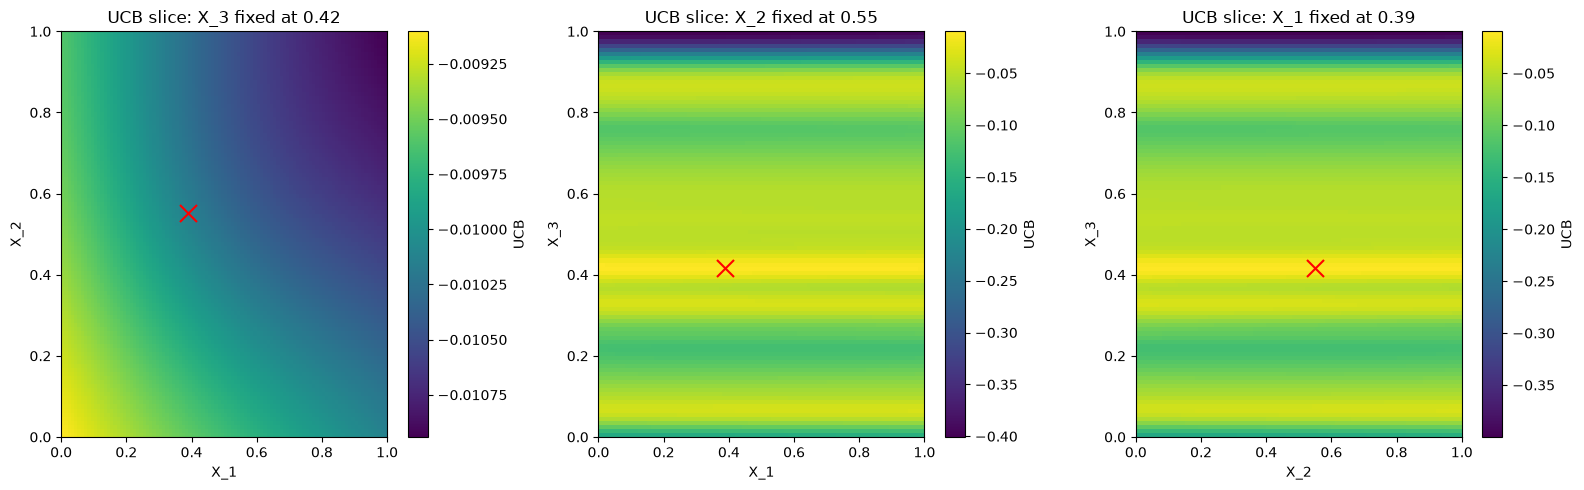

In [108]:
grid_res   = 100
lin        = np.linspace(0, 1, grid_res)
pairs      = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]  # (dim_x, dim_y, dim_fixed)

fig, axes  = plt.subplots(1, 3, figsize=(16, 5))
for ax, (dx, dy, dfixed) in zip(axes, pairs):
    gx, gy                 = np.meshgrid(lin, lin)
    grid_points            = np.zeros((grid_res * grid_res, 3))
    grid_points[:, dx]     = gx.ravel()
    grid_points[:, dy]     = gy.ravel()
    grid_points[:, dfixed] = next_point[dfixed]

    mu_grid, std_grid      = gpr.predict(grid_points, return_std = True)
    ucb_grid               = (mu_grid + beta * std_grid).reshape(grid_res, grid_res)

    im                     = ax.imshow(ucb_grid, origin = "lower", extent = [0, 1, 0, 1], cmap = "viridis", aspect = "auto")
    ax.set_xlabel(labels[dx]); ax.set_ylabel(labels[dy])
    ax.set_title(f"UCB slice: {labels[dfixed]} fixed at {next_point[dfixed]:.2f}")
    ax.scatter(next_point[dx], next_point[dy], c = "red", marker = "x", s = 150, edgecolor = "black")
    plt.colorbar(im, ax = ax, label = "UCB")

plt.tight_layout()
plt.show()

# Week 9: Strategy - Tightening the Local Search Further
**Reason:** With the moderate-region hypothesis now reinforced by a Week 8's new best-result, continuing exploiting. The search bound is tightened further (+/-0.15 -> +/-0.08) and beta lowered slightly (0.3 to 0.2), refining closely around the new best point.

In [111]:
# Tighter local search around the new best point
current_best_x = X[np.argmax(Y)]
delta          = 0.08  # WEEK 9 CHANGE: tightened from 0.15
lower_bound    = np.clip(current_best_x - delta, 0, 1)
upper_bound    = np.clip(current_best_x + delta, 0, 1)
print(f"Current best point: {current_best_x}")
print(f"Local search bounds: lower={lower_bound}, upper={upper_bound}")

n_candidates = 50000
candidates   = np.random.uniform(lower_bound, upper_bound, size=(n_candidates, 3))

mu, std = gpr.predict(candidates, return_std=True)

beta = 0.2  # WEEK 9 CHANGE: lowered from 0.3, refining closely around the confirmed best region
ucb  = mu + beta * std

best_ucb_idx = np.argmax(ucb)
next_point   = candidates[best_ucb_idx]

print(f"\nSuggested next Query Point (tighter local search): {next_point}")
print(f"Predicted Mean(mu): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (sigma): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Current best point: [0.538784 0.682926 0.415306]
Local search bounds: lower=[0.458784 0.602926 0.335306], upper=[0.618784 0.762926 0.495306]

Suggested next Query Point (tighter local search): [0.45909637 0.60872194 0.41667185]
Predicted Mean(mu): -1.426709e-02
Predicted Std (sigma): 1.323427e-02
UCB Score: -1.162024e-02


# Week 9: UCB Landscape Visualisation

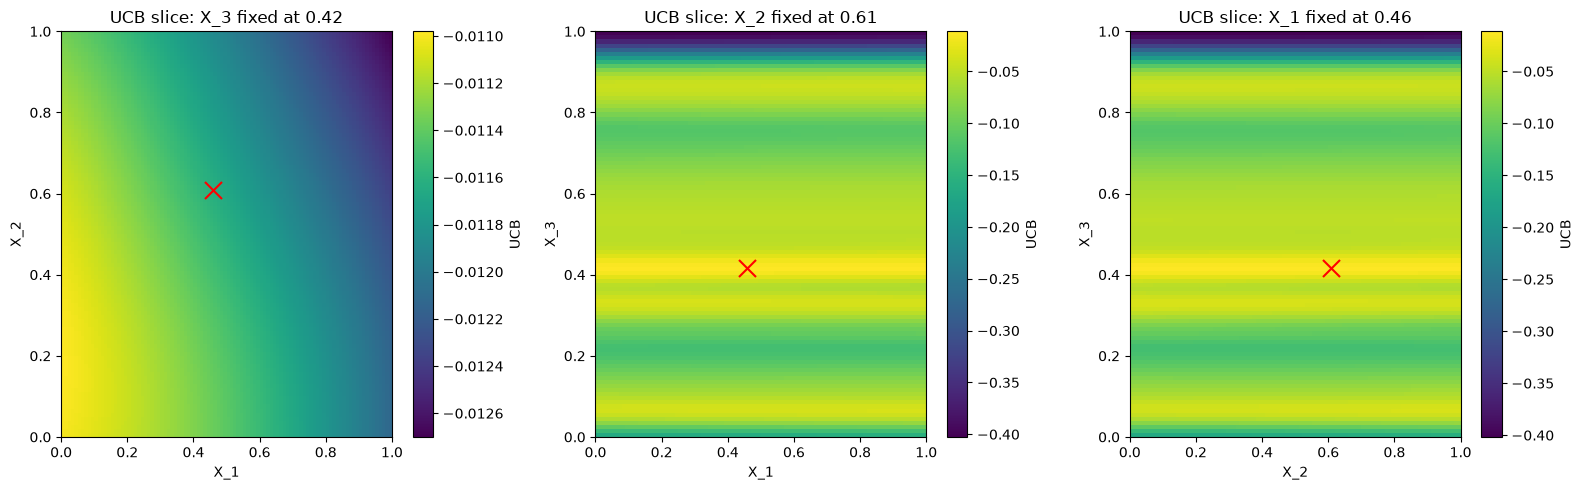

In [114]:
grid_res   = 100
lin        = np.linspace(0, 1, grid_res)
pairs      = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]  # (dim_x, dim_y, dim_fixed)

fig, axes  = plt.subplots(1, 3, figsize=(16, 5))
for ax, (dx, dy, dfixed) in zip(axes, pairs):
    gx, gy                 = np.meshgrid(lin, lin)
    grid_points            = np.zeros((grid_res * grid_res, 3))
    grid_points[:, dx]     = gx.ravel()
    grid_points[:, dy]     = gy.ravel()
    grid_points[:, dfixed] = next_point[dfixed]

    mu_grid, std_grid      = gpr.predict(grid_points, return_std = True)
    ucb_grid               = (mu_grid + beta * std_grid).reshape(grid_res, grid_res)

    im                     = ax.imshow(ucb_grid, origin = "lower", extent = [0, 1, 0, 1], cmap = "viridis", aspect = "auto")
    ax.set_xlabel(labels[dx]); ax.set_ylabel(labels[dy])
    ax.set_title(f"UCB slice: {labels[dfixed]} fixed at {next_point[dfixed]:.2f}")
    ax.scatter(next_point[dx], next_point[dy], c = "red", marker = "x", s = 150, edgecolor = "black")
    plt.colorbar(im, ax = ax, label = "UCB")

plt.tight_layout()
plt.show()

# Portal Submission 

In [116]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}"
print("Points to be submitted (Week 1):", '0.989736-0.937592-0.849609')
print("Points to be submitted (Week 2):", '0.130658-0.076877-0.000068')
print("Points to be submitted (Week 3):", '0.990706-0.795157-0.087796')
print("Points to be submitted (Week 4):", '0.969416-0.964611-0.393406')  
print("Points to be submitted (Week 5):", '0.683102-0.806806-0.392104') 
print("Points to be submitted (Week 6):", '0.981431-0.950647-0.511337') 
print("Points to be submitted (Week 7):", '0.977494-0.997588-0.372098')
print("Points to be submitted (Week 8):", '0.538784-0.682926-0.415306')
print("Points to be submitted (Week 9):", submission_str) 

Points to be submitted (Week 1): 0.989736-0.937592-0.849609
Points to be submitted (Week 2): 0.130658-0.076877-0.000068
Points to be submitted (Week 3): 0.990706-0.795157-0.087796
Points to be submitted (Week 4): 0.969416-0.964611-0.393406
Points to be submitted (Week 5): 0.683102-0.806806-0.392104
Points to be submitted (Week 6): 0.981431-0.950647-0.511337
Points to be submitted (Week 7): 0.977494-0.997588-0.372098
Points to be submitted (Week 8): 0.538784-0.682926-0.415306
Points to be submitted (Week 9): 0.459096-0.608722-0.416672


# Plot the Progress of the optimisation process

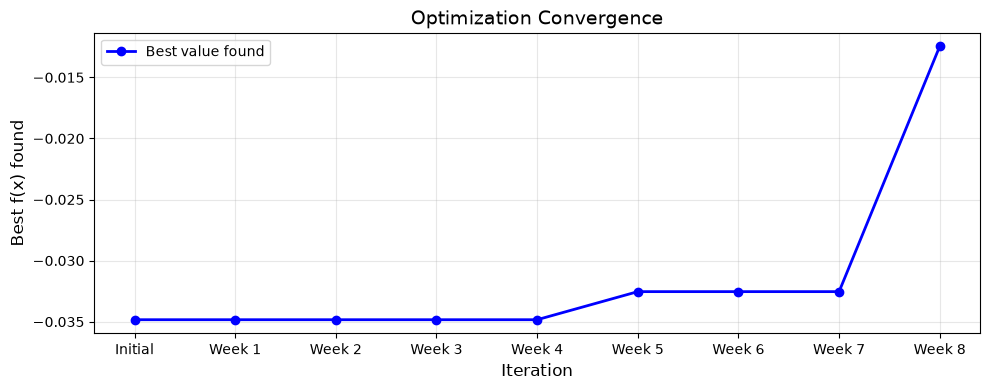

Best value found so far: -0.012460149936303126


In [119]:
# Track best-value-found progress across weeks
best_so_far = [
    -0.034835313350078584,                                 # best after initial 15 points
    max(-0.034835313350078584, -0.04976805147714386),      # best after Week 1
    max(-0.034835313350078584, -0.17308602208694687),      # best after Week 2
    max(-0.034835313350078584, -0.05549717617041605),      # best after Week 3 (corrected)
    max(-0.034835313350078584, -0.082473716892482),        # best after Week 4  
    max(-0.034835313350078584, -0.03253700291950847),      # best after Week 5
    max(-0.03253700291950847,  -0.054925397272106755),     # best after Week 6
    max(-0.03253700291950847,  -0.06792216897886878),      # best after Week 7
    max(-0.03253700291950847,  -0.012460149936303126),     # best after Week 8
]

fig, ax     = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(['Initial', 'Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week 5', 'Week 6', 'Week 7', 'Week 8'])
plt.show()

print("Best value found so far:", max(best_so_far))